<a href="https://colab.research.google.com/github/sabamahmoud-cyber/Adult-Income-Prediction/blob/main/Adult_Income.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Adult Income Prediction

## Project Overview

The goal of this project is to predict whether an individual's annual income is above or below $50K based on demographic and employment information.

The project includes:

- Exploring and cleaning the dataset
- Creating exploratory visualizations
- Preprocessing the data
- Training and evaluating a default classification model
- Identifying the top 10 features using permutation importance
- Creating explanatory visualizations for important features

##  Import Libraries

The required libraries are imported for data analysis, visualization, preprocessing, modeling, and evaluation.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score
)

from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", None)

##  Load the Dataset

The Adult Income dataset is loaded into a pandas DataFrame.

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/axsos-dataset/adult.csv")

df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


##  Explore the Dataset

The dataset is inspected to understand its size, columns, data types, and summary statistics.

In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 48842
Number of columns: 15


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
fnlwgt,48842.0,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
educational-num,48842.0,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0
capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0


In [ ]:
df.describe(include="object").T

,count,unique,top,freq
workclass,48842,9,Private,33906
education,48842,16,HS-grad,15784
marital-status,48842,7,Married-civ-spouse,22379
occupation,48842,15,Prof-specialty,6172
relationship,48842,6,Husband,19716
race,48842,5,White,41762
gender,48842,2,Male,32650
native-country,48842,42,United-States,43832
income,48842,2,<=50K,37155


## 4. Data Cleaning

Column names and categorical values are cleaned to make them consistent and easier to use.

In [ ]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace("-", "_", regex=False)
)

df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'educational_num',
       'marital_status', 'occupation', 'relationship', 'race', 'gender',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income'],
      dtype='object')

### Clean Categorical Values

Extra spaces are removed from categorical values. Periods are also removed from the target values if they exist.

In [ ]:
categorical_columns = df.select_dtypes(
    include="object"
).columns

for col in categorical_columns:
    df[col] = df[col].str.strip()

In [ ]:
df["income"] = df["income"].str.replace(
    ".",
    "",
    regex=False
)

In [ ]:
df["income"].value_counts()

,count
income,
<=50K,37155
>50K,11687


### Missing Values

Some missing categorical values are represented by a question mark. These values are converted to proper missing values before further analysis.

In [ ]:
for col in categorical_columns:
    count = (df[col] == "?").sum()

    if count > 0:
        print(col, ":", count)

workclass : 2799
occupation : 2809
native_country : 857


In [ ]:
df = df.replace("?", np.nan)

In [ ]:
df.isna().sum()

,0
age,0
workclass,2799
fnlwgt,0
education,0
educational_num,0
marital_status,0
occupation,2809
relationship,0
race,0
gender,0


### Investigating Missing Values

The rows containing missing values are filtered and compared with the available data before selecting a missing-value treatment.

In [ ]:
df[df["workclass"].isna()].head()

,age,workclass,fnlwgt,education,educational_num,marital_status,occupation,relationship,race,gender,capital_gain,capital_loss,hours_per_week,native_country,income
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K
6,29,NaN,227026,HS-grad,9,Never-married,NaN,Unmarried,Black,Male,0,0,40,United-States,<=50K
13,58,NaN,299831,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,35,United-States,<=50K
22,72,NaN,132015,7th-8th,4,Divorced,NaN,Not-in-family,White,Female,0,0,6,United-States,<=50K
35,65,NaN,191846,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,40,United-States,<=50K


In [ ]:
pd.crosstab(
    df["occupation"],
    df["workclass"],
    normalize="index"
).round(2)

workclass,Federal-gov,Local-gov,Private,Self-emp-inc,Self-emp-not-inc,State-gov,Without-pay
occupation,,,,,,,
Adm-clerical,0.09,0.08,0.75,0.01,0.01,0.07,0.00
Armed-Forces,1.00,0.00,0.00,0.00,0.00,0.00,0.00
Craft-repair,0.02,0.03,0.78,0.03,0.13,0.02,0.00
Exec-managerial,0.04,0.05,0.66,0.10,0.10,0.05,0.00
Farming-fishing,0.01,0.03,0.45,0.06,0.44,0.02,0.01
Handlers-cleaners,0.02,0.03,0.93,0.00,0.01,0.01,0.00
Machine-op-inspct,0.01,0.01,0.95,0.01,0.02,0.01,0.00
Other-service,0.01,0.06,0.82,0.01,0.06,0.04,0.00
Priv-house-serv,0.00,0.00,1.00,0.00,0.00,0.00,0.00


In [ ]:
df[df["occupation"].isna()].head()

,age,workclass,fnlwgt,education,educational_num,marital_status,occupation,relationship,race,gender,capital_gain,capital_loss,hours_per_week,native_country,income
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K
6,29,NaN,227026,HS-grad,9,Never-married,NaN,Unmarried,Black,Male,0,0,40,United-States,<=50K
13,58,NaN,299831,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,35,United-States,<=50K
22,72,NaN,132015,7th-8th,4,Divorced,NaN,Not-in-family,White,Female,0,0,6,United-States,<=50K
35,65,NaN,191846,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,40,United-States,<=50K


In [ ]:
pd.crosstab(
    df["workclass"],
    df["occupation"],
    normalize="index"
).round(2)

occupation,Adm-clerical,Armed-Forces,Craft-repair,Exec-managerial,Farming-fishing,Handlers-cleaners,Machine-op-inspct,Other-service,Priv-house-serv,Prof-specialty,Protective-serv,Sales,Tech-support,Transport-moving
workclass,,,,,,,,,,,,,,
Federal-gov,0.34,0.01,0.06,0.19,0.01,0.03,0.01,0.04,0.00,0.18,0.03,0.01,0.07,0.03
Local-gov,0.13,0.00,0.07,0.11,0.01,0.02,0.01,0.10,0.00,0.34,0.14,0.01,0.02,0.05
Private,0.12,0.00,0.14,0.12,0.02,0.06,0.08,0.12,0.01,0.10,0.01,0.13,0.03,0.06
Self-emp-inc,0.03,0.00,0.10,0.36,0.05,0.00,0.01,0.02,0.00,0.14,0.00,0.25,0.01,0.02
Self-emp-not-inc,0.02,0.00,0.21,0.15,0.17,0.01,0.02,0.07,0.00,0.15,0.00,0.15,0.01,0.05
State-gov,0.19,0.00,0.05,0.14,0.01,0.01,0.01,0.10,0.00,0.32,0.09,0.01,0.04,0.03
Without-pay,0.14,0.00,0.05,0.05,0.38,0.10,0.10,0.10,0.00,0.00,0.00,0.05,0.00,0.05


In [ ]:
df[df["native_country"].isna()].head()

,age,workclass,fnlwgt,education,educational_num,marital_status,occupation,relationship,race,gender,capital_gain,capital_loss,hours_per_week,native_country,income
19,40,Private,85019,Doctorate,16,Married-civ-spouse,Prof-specialty,Husband,Asian-Pac-Islander,Male,0,0,45,NaN,>50K
65,41,Private,109912,Bachelors,13,Never-married,Other-service,Not-in-family,White,Female,0,0,40,NaN,<=50K
83,44,Self-emp-inc,223881,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,99999,0,50,NaN,>50K
188,34,State-gov,513100,Bachelors,13,Married-spouse-absent,Farming-fishing,Not-in-family,Black,Male,0,0,40,NaN,<=50K
253,42,Federal-gov,177937,Bachelors,13,Never-married,Prof-specialty,Not-in-family,White,Male,0,0,40,NaN,<=50K


In [ ]:
df["native_country"].value_counts(
    normalize=True
).head(10)

,proportion
native_country,
United-States,0.913452
Mexico,0.019819
Philippines,0.006148
Germany,0.004293
Puerto-Rico,0.003835
Canada,0.003793
El-Salvador,0.003230
India,0.003147
Cuba,0.002876


### Missing Values Observation

The missing values in `workclass`, `occupation`, and `native_country` were investigated using filters and normalized cross-tabulations.

Most records with a missing `workclass` also had a missing `occupation`, so one feature could not be used to infer the other.

The cross-tabulations also showed that each occupation can belong to multiple work classes. Therefore, there was not enough evidence to assign an exact category confidently.

Although the United States was the most frequent native country, assigning it to every missing record could introduce bias.

For this reason, the missing categorical values will be represented by a separate `Unknown` category inside the preprocessing pipeline.

### Duplicates and Invalid Values

Duplicated records and possible invalid numerical values are inspected before modeling.

In [ ]:
print(
    "Duplicated rows:",
    df.duplicated().sum()
)

Duplicated rows: 52


In [ ]:
print("Invalid ages:", (df["age"] <= 0).sum())

print(
    "Invalid education values:",
    (df["educational_num"] <= 0).sum()
)

print(
    "Invalid working hours:",
    (
        (df["hours_per_week"] <= 0) |
        (df["hours_per_week"] > 168)
    ).sum()
)

print(
    "Negative capital gain:",
    (df["capital_gain"] < 0).sum()
)

print(
    "Negative capital loss:",
    (df["capital_loss"] < 0).sum()
)

Invalid ages: 0
Invalid education values: 0
Invalid working hours: 0
Negative capital gain: 0
Negative capital loss: 0


## 5. Exploratory Data Analysis

### Income Class Distribution

This visualization shows the distribution of the target classes and helps determine whether the dataset is balanced.

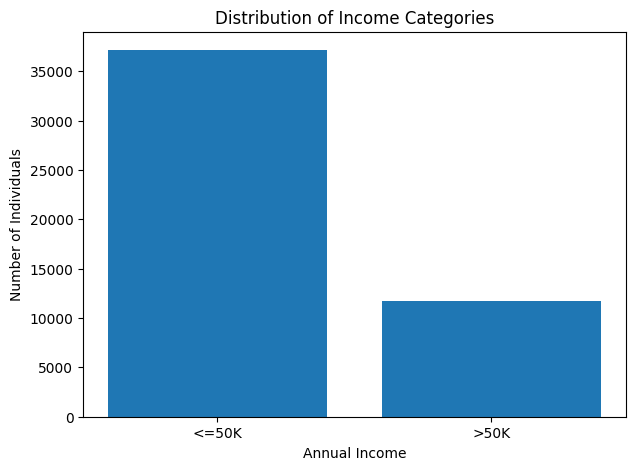

In [ ]:
income_counts = df["income"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    income_counts.index,
    income_counts.values
)

plt.title("Distribution of Income Categories")
plt.xlabel("Annual Income")
plt.ylabel("Number of Individuals")
plt.xticks(rotation=0)
plt.show()

### Observation

The dataset is imbalanced. Approximately 76% of individuals earn $50K or less, while only about 24% earn above $50K.

Because of this imbalance, accuracy alone may not provide a complete evaluation of the model. Precision, recall, F1-score, and ROC-AUC should also be considered.

### Income by Education Level

This visualization examines how the income distribution changes across education levels.

In [ ]:
education_income = (
    df.groupby(["educational_num", "education"])["income"]
    .apply(lambda x: (x == ">50K").mean() * 100)
    .reset_index(name="percentage_above_50k")
    .sort_values("educational_num")
)

education_income

,educational_num,education,percentage_above_50k
0,1,Preschool,1.204819
1,2,1st-4th,3.238866
2,3,5th-6th,5.304519
3,4,7th-8th,6.492147
4,5,9th,5.423280
5,6,10th,6.263499
6,7,11th,5.077263
7,8,12th,7.305936
8,9,HS-grad,15.857831
9,10,Some-college,18.964883


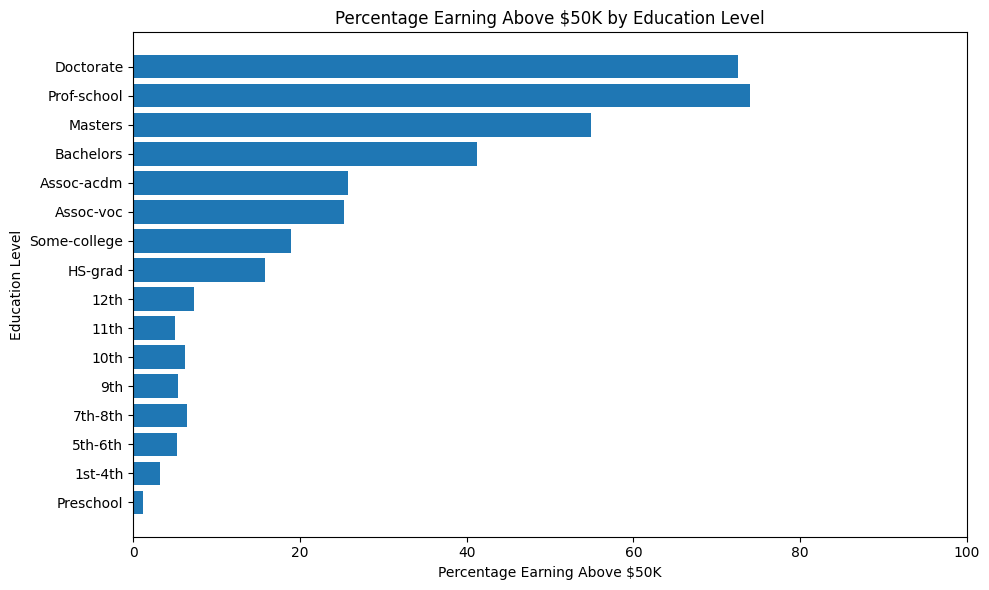

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    education_income["education"],
    education_income["percentage_above_50k"]
)

plt.title("Percentage Earning Above $50K by Education Level")
plt.xlabel("Percentage Earning Above $50K")
plt.ylabel("Education Level")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

### Observation

The percentage of individuals earning above $50K generally increases with higher education levels.

Professional school, doctorate, and master's graduates have the highest high-income percentages, while individuals with lower education levels show much smaller percentages.

This suggests that education level is strongly associated with income. However, education is not the only factor that affects an individual's income.

### High-Income Percentage by Occupation

This visualization compares the percentage of individuals earning above $50K across different occupations.

In [ ]:
occupation_income = (
    df.groupby("occupation")["income"]
    .apply(lambda x: (x == ">50K").mean() * 100)
    .sort_values()
)

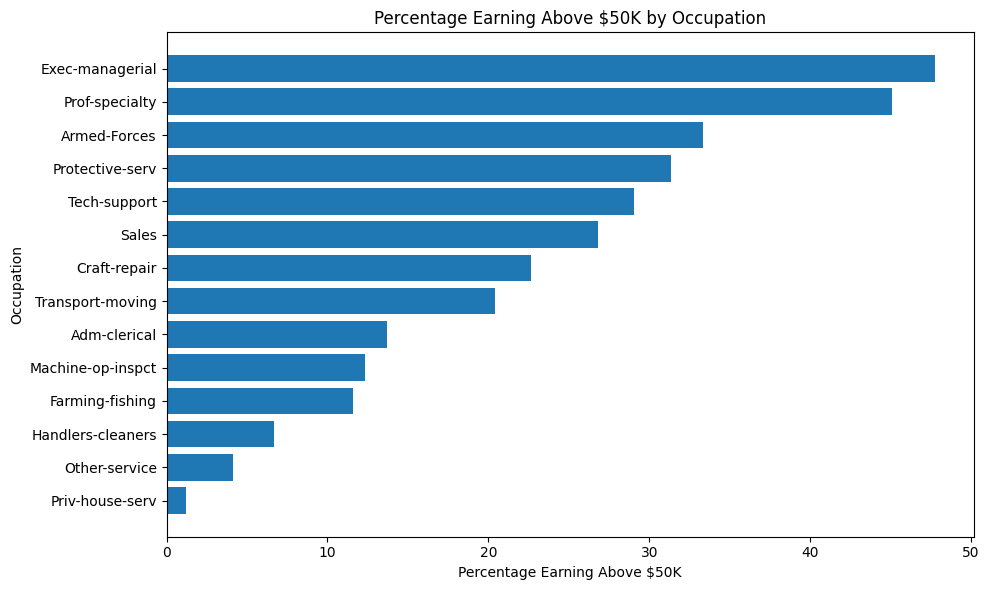

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    occupation_income.index,
    occupation_income.values
)

plt.title("Percentage Earning Above $50K by Occupation")
plt.xlabel("Percentage Earning Above $50K")
plt.ylabel("Occupation")
plt.tight_layout()
plt.show()

### Observation

Income patterns vary considerably across occupations.

Executive-managerial and professional-specialty occupations show the highest percentages of individuals earning above $50K. In contrast, private household services, other services, and handler-cleaner occupations show much lower percentages.

This information may help stakeholders understand which occupational groups are more strongly associated with higher income levels.

The Armed Forces result should be interpreted carefully because this occupation may contain a relatively small number of records.

## 6. Feature Selection

The `education` and `educational_num` columns are examined because they may represent the same information.

In [ ]:
df[
    ["education", "educational_num"]
].drop_duplicates().sort_values(
    "educational_num"
)

,education,educational_num
779,Preschool,1
323,1st-4th,2
37,5th-6th,3
9,7th-8th,4
54,9th,5
5,10th,6
0,11th,7
173,12th,8
1,HS-grad,9
3,Some-college,10


In [ ]:
df.groupby("education")[
    "educational_num"
].nunique()

,educational_num
education,
10th,1
11th,1
12th,1
1st-4th,1
5th-6th,1
7th-8th,1
9th,1
Assoc-acdm,1
Assoc-voc,1


In [ ]:
df = df.drop(
    columns=["education"]
)

### Feature Selection Decision

Each category in the `education` column corresponds to exactly one value in `educational_num`.

Therefore, both columns represent the same education information. The `education` column will be removed to avoid keeping duplicate information, while `educational_num` will be retained because it preserves the natural order of education levels.

## 7. Prepare Features and Target

The input features are separated from the target variable. The target is converted into numerical values for classification.

In [ ]:
X = df.drop(
    columns=["income"]
)

y = df["income"].map({
    "<=50K": 0,
    ">50K": 1
})

In [ ]:
y.value_counts(dropna=False)

,count
income,
0,37155
1,11687


## 8. Train-Test Split

The dataset is divided into training and testing sets. Stratification is used to preserve the original income-class distribution.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (39073, 13)
Testing data: (9769, 13)


## 9. Data Preprocessing

Numerical and categorical features require different preprocessing steps.

- Numerical missing values are filled using the median.
- Categorical missing values are filled using the most frequent category.
- Categorical variables are converted into numerical columns using one-hot encoding.

All preprocessing steps are placed inside a pipeline to avoid data leakage.

In [ ]:
numeric_features = [
    "age",
    "fnlwgt",
    "educational_num",
    "capital_gain",
    "capital_loss",
    "hours_per_week"
]

categorical_features = [
    "workclass",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "gender",
    "native_country"
]

In [ ]:
numeric_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    )
])

In [ ]:
categorical_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="constant",
            fill_value="Unknown"
        )
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

In [ ]:
preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_transformer,
        numeric_features
    ),
    (
        "categorical",
        categorical_transformer,
        categorical_features
    )
])

## 10. Fit a Default Model

A Random Forest classifier is selected because it can capture non-linear relationships and interactions between the features.

The default model settings are used without hyperparameter tuning.

In [ ]:
model_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        RandomForestClassifier(
            random_state=42
        )
    )
])

In [ ]:
model_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['age', 'fnlwgt',
                                                   'educational_num',
                                                   'capital_gain',
                                                   'capital_loss',
                                                   'hours_per_week']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['workclass',
                                                   'marital_status',
                                                   'occupation', 'relationship',
                                                   'race', 'gender',
                                                   'native_country'])])),
                ('model', RandomForestClassifier(random_state=42))])

## 11. Model Evaluation

The model is evaluated using accuracy, ROC-AUC, precision, recall, F1-score, and a confusion matrix.

Multiple metrics are used because the target classes are imbalanced.

In [ ]:
y_pred = model_pipeline.predict(
    X_test
)

y_prob = model_pipeline.predict_proba(
    X_test
)[:, 1]

In [ ]:
print(
    "Accuracy:",
    round(
        accuracy_score(y_test, y_pred),
        3
    )
)

print(
    "ROC-AUC:",
    round(
        roc_auc_score(y_test, y_prob),
        3
    )
)

Accuracy: 0.86
ROC-AUC: 0.906


In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "<=50K",
            ">50K"
        ]
    )
)

              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      7431
        >50K       0.75      0.62      0.68      2338

    accuracy                           0.86      9769
   macro avg       0.82      0.78      0.80      9769
weighted avg       0.85      0.86      0.86      9769



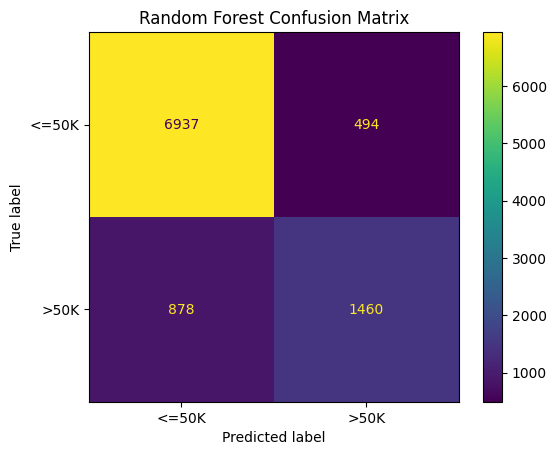

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=[
        "<=50K",
        ">50K"
    ]
)

plt.title("Random Forest Confusion Matrix")
plt.show()

### Model Evaluation Observation

The default Random Forest model achieved an accuracy of 0.86 and a ROC-AUC score of 0.906, indicating good overall classification and discrimination performance.

The model performed particularly well for individuals earning $50K or less, with a recall of 0.93 and an F1-score of 0.91.

For the above-$50K class, the model achieved a precision of 0.75, a recall of 0.62, and an F1-score of 0.68. The lower recall indicates that the model missed some individuals who actually earned above $50K.

The confusion matrix shows that 6,937 lower-income and 1,460 higher-income records were classified correctly. However, 878 higher-income records were incorrectly classified as earning $50K or less.

Overall, the model provides strong baseline performance, but it is more effective at identifying the majority class than the smaller above-$50K class.

## 12. Permutation Feature Importance

Permutation importance measures how much the model's performance decreases when the values of each feature are shuffled.

A larger decrease indicates that the feature is more important to the model.

In [ ]:
importance_result = permutation_importance(
    model_pipeline,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring="f1",
    n_jobs=-1
)

In [ ]:
importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": importance_result.importances_mean
}).sort_values(
    "Importance",
    ascending=False
)

top_10_features = importance_df.head(10)

top_10_features

,Feature,Importance
4,marital_status,0.113474
9,capital_gain,0.091068
6,relationship,0.075080
3,educational_num,0.071733
5,occupation,0.063110
0,age,0.053676
11,hours_per_week,0.034161
10,capital_loss,0.021499
8,gender,0.015521
1,workclass,0.012195


### Top 10 Important Features

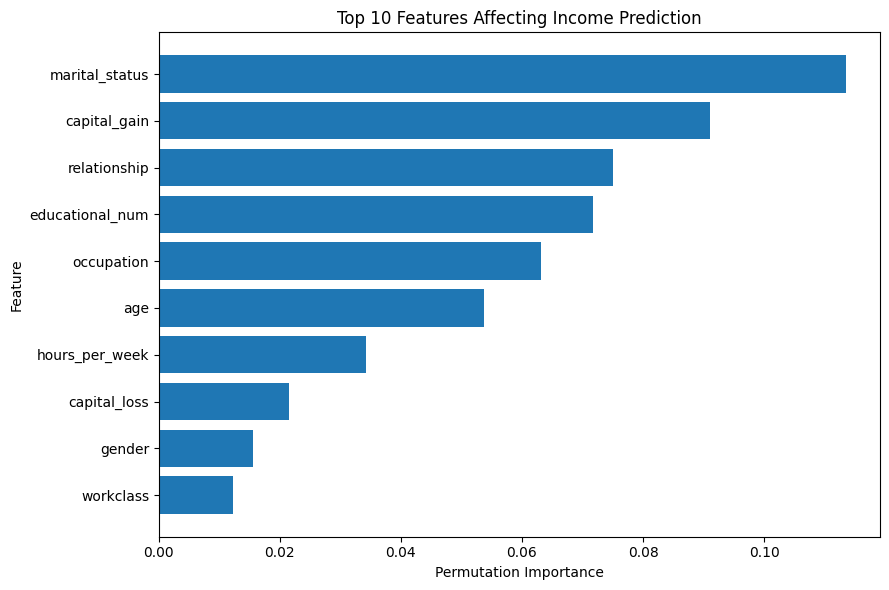

In [ ]:
plt.figure(figsize=(9, 6))

plt.barh(
    top_10_features["Feature"][::-1],
    top_10_features["Importance"][::-1]
)

plt.title("Top 10 Features Affecting Income Prediction")
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Feature Importance Observation

The permutation importance results show that `marital_status` had the greatest effect on the model's performance, followed by `capital_gain`, `relationship`, `educational_num`, and `occupation`.

These results are reasonable for the income prediction problem. Financial indicators, education, occupation, household structure, age, and working hours can all be associated with differences in income.

However, these features show associations in the dataset and should not be interpreted as direct causes of income.

## 13. Explanatory Visualizations

### Percentage Earning Above $50K by Marital Status

`marital_status` was the most important feature according to permutation importance. This visualization compares the percentage of individuals earning above $50K across marital-status categories.

In [ ]:
high_income = (df["income"] == ">50K").astype(int)

marital_income = (
    df.assign(high_income=high_income)
    .groupby("marital_status")["high_income"]
    .mean()
    .mul(100)
    .sort_values()
)

marital_income

,high_income
marital_status,
Never-married,4.547993
Separated,6.470588
Widowed,8.432148
Married-spouse-absent,9.235669
Divorced,10.116086
Married-AF-spouse,37.837838
Married-civ-spouse,44.613253


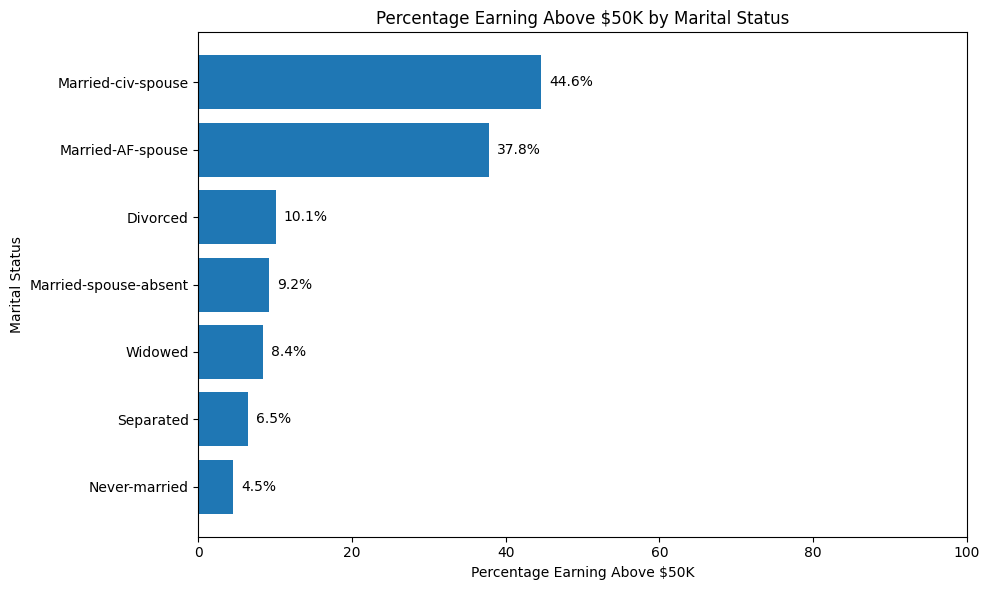

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    marital_income.index,
    marital_income.values
)

plt.title("Percentage Earning Above $50K by Marital Status")
plt.xlabel("Percentage Earning Above $50K")
plt.ylabel("Marital Status")
plt.xlim(0, 100)

for i, value in enumerate(marital_income.values):
    plt.text(
        value + 1,
        i,
        f"{value:.1f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

### Marital Status Insight

The percentage of individuals earning above $50K varies clearly across marital-status categories.

The `Married-civ-spouse` category has the highest high-income percentage at 44.6%, followed by `Married-AF-spouse` at 37.8%. In comparison, only 4.5% of individuals in the `Never-married` category earn above $50K.

This result supports the permutation importance findings and shows that marital status is strongly associated with income patterns. However, marital status should not be interpreted as a direct cause of higher income, since factors such as age, work experience, education, and occupation may also contribute.

### Percentage Earning Above $50K by Capital Gain Status

`capital_gain` was the second most important feature. The records are divided into individuals who reported a capital gain and individuals who did not.

In [ ]:
capital_gain_data = df.assign(
    high_income=high_income,
    capital_gain_status=np.where(
        df["capital_gain"] > 0,
        "Reported capital gain",
        "No capital gain"
    )
)

capital_gain_income = (
    capital_gain_data
    .groupby("capital_gain_status")["high_income"]
    .mean()
    .mul(100)
    .sort_values()
)

capital_gain_income

,high_income
capital_gain_status,
No capital gain,20.523579
Reported capital gain,61.734820


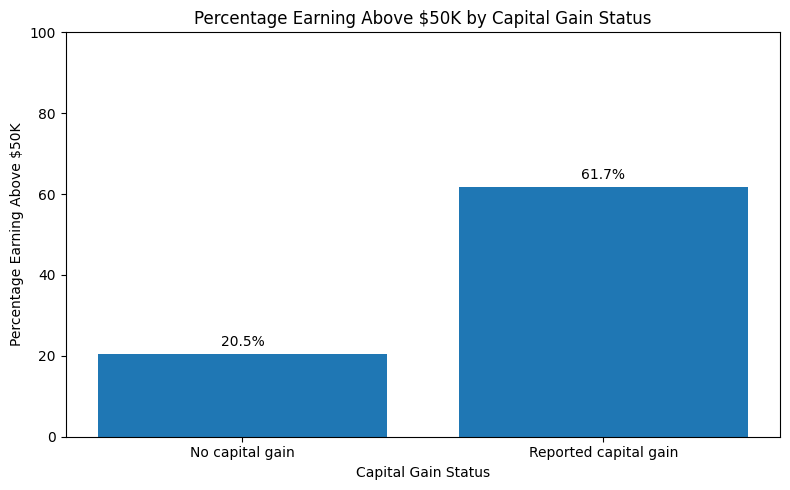

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))

plt.bar(
    capital_gain_income.index,
    capital_gain_income.values
)

plt.title("Percentage Earning Above $50K by Capital Gain Status")
plt.xlabel("Capital Gain Status")
plt.ylabel("Percentage Earning Above $50K")
plt.ylim(0, 100)
plt.tight_layout()
for i, value in enumerate(capital_gain_income.values):
    plt.text(
        i,
        value + 2,
        f"{value:.1f}%",
        ha="center"
    )
plt.show()

### Capital Gain Insight

Individuals who reported a capital gain were much more likely to earn above $50K.

Approximately 61.7% of individuals with a reported capital gain earned above $50K, compared with only 20.5% of individuals who reported no capital gain.

This supports the permutation importance result and shows that `capital_gain` is a useful financial indicator for income prediction. However, this relationship represents an association and does not mean that capital gain alone determines income.

## Conclusion

In this project, the Adult Income dataset was explored, cleaned, and prepared to predict whether an individual's annual income is above or below $50K.

Missing values in `workclass`, `occupation`, and `native_country` were investigated before preprocessing. Since the exact values could not be determined confidently, they were represented as an `Unknown` category. The `education` column was removed because it contained the same information as `educational_num`.

A default Random Forest model achieved an accuracy of 0.86 and a ROC-AUC score of 0.906. The model performed well overall, but it was better at identifying individuals earning $50K or less. For the above-$50K class, the model achieved an F1-score of 0.68 and missed some higher-income individuals.

Permutation importance showed that `marital_status`, `capital_gain`, `relationship`, `educational_num`, and `occupation` were among the most influential features.

The explanatory visualizations showed that 61.7% of individuals who reported a capital gain earned above $50K, compared with 20.5% of individuals with no capital gain. Income patterns also varied across marital-status categories, with the `Married-civ-spouse` group having the highest percentage of individuals earning above $50K.

Overall, the results suggest that income is associated with a combination of financial, educational, demographic, and employment-related factors. These relationships represent patterns in the dataset and should not be interpreted as direct causes of income.

# Project 4 - Part 2: Feature Engineering and Feature Selection

In this section, new features are created from the existing data.

The model performance will be compared before and after feature engineering. An embedded feature-selection method will then be applied to build a final model using the most useful features.

## 1. Save the Part 1 Results

In [ ]:
from sklearn.metrics import f1_score
from sklearn.feature_selection import SelectFromModel

part1_predictions = y_pred.copy()
part1_probabilities = y_prob.copy()
part1_top_features = top_10_features.copy()

part1_accuracy = accuracy_score(y_test, part1_predictions)
part1_f1 = f1_score(y_test, part1_predictions)
part1_roc_auc = roc_auc_score(y_test, part1_probabilities)

## 2. Feature Engineering

Two new features are created:

- `capital_status`: summarizes whether an individual reported a capital gain, a capital loss, both, or neither.
- `work_hours_group`: groups weekly working hours into part-time, standard, and long working hours.

These features were selected because capital activity and working hours showed meaningful relationships with income during Part 1.

In [ ]:
def add_engineered_features(data):
    data = data.copy()

    conditions = [
        (data["capital_gain"] > 0) & (data["capital_loss"] > 0),
        data["capital_gain"] > 0,
        data["capital_loss"] > 0
    ]

    choices = [
        "Gain and loss",
        "Capital gain",
        "Capital loss"
    ]

    data["capital_status"] = np.select(
        conditions,
        choices,
        default="No capital activity"
    )

    data["work_hours_group"] = pd.cut(
        data["hours_per_week"],
        bins=[0, 34, 45, np.inf],
        labels=[
            "Part-time",
            "Standard hours",
            "Long hours"
        ]
    ).astype(str)

    return data

In [ ]:
X_train_fe = add_engineered_features(X_train)
X_test_fe = add_engineered_features(X_test)

X_train_fe[
    [
        "capital_gain",
        "capital_loss",
        "capital_status",
        "hours_per_week",
        "work_hours_group"
    ]
].head()

,capital_gain,capital_loss,capital_status,hours_per_week,work_hours_group
34342,0,0,No capital activity,17,Part-time
18559,0,0,No capital activity,10,Part-time
12477,0,0,No capital activity,40,Standard hours
560,0,0,No capital activity,40,Standard hours
3427,0,0,No capital activity,40,Standard hours


The engineered features are created separately for the training and testing data. The target variable is not used during feature creation, so no target leakage is introduced.

## 3. Preprocessing the Engineered Data

In [ ]:
numeric_features_fe = numeric_features.copy()

categorical_features_fe = categorical_features + [
    "capital_status",
    "work_hours_group"
]

In [ ]:
preprocessor_fe = ColumnTransformer([
    (
        "numeric",
        numeric_transformer,
        numeric_features_fe
    ),
    (
        "categorical",
        categorical_transformer,
        categorical_features_fe
    )
])

## 4. Model with Engineered Features

In [ ]:
engineered_model = Pipeline([
    (
        "preprocessor",
        preprocessor_fe
    ),
    (
        "model",
        RandomForestClassifier(
            random_state=42
        )
    )
])

In [ ]:
engineered_model.fit(
    X_train_fe,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['age', 'fnlwgt',
                                                   'educational_num',
                                                   'capital_gain',
                                                   'capital_loss',
                                                   'hours_per_week']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['workclass',
                                                   'marital_status',
                                                   'occupation', 'relationship',
                                                   'race', 'gender',
                                                   'native_country',
                                                   'capital_status',
                                                   'work_hours_group'])])),
                ('model', RandomForestClassifier(random_state=42))])

In [ ]:
engineered_predictions = engineered_model.predict(
    X_test_fe
)

engineered_probabilities = engineered_model.predict_proba(
    X_test_fe
)[:, 1]

## 5. Feature Engineering Comparison

In [ ]:
engineering_comparison = pd.DataFrame({
    "Model": [
        "Part 1 - Original Features",
        "Part 2 - Engineered Features"
    ],
    "Accuracy": [
        part1_accuracy,
        accuracy_score(
            y_test,
            engineered_predictions
        )
    ],
    "F1 Score": [
        part1_f1,
        f1_score(
            y_test,
            engineered_predictions
        )
    ],
    "ROC-AUC": [
        part1_roc_auc,
        roc_auc_score(
            y_test,
            engineered_probabilities
        )
    ]
})

engineering_comparison.round(3)

,Model,Accuracy,F1 Score,ROC-AUC
0,Part 1 - Original Features,0.86,0.680,0.906
1,Part 2 - Engineered Features,0.86,0.683,0.906


### Feature Engineering Observation

The feature-engineered model achieved a small improvement in F1-score, increasing from 0.680 to 0.683.

Accuracy remained at 0.86, while ROC-AUC remained at 0.906. This indicates that the engineered features provided a slight improvement in identifying the above-$50K class, although the overall change was small.

The engineered features summarize capital activity and weekly working-hour patterns in a simpler and more meaningful form.

## 6. Embedded Feature Selection

In [ ]:
final_model = Pipeline([
    (
        "preprocessor",
        preprocessor_fe
    ),
    (
        "feature_selection",
        SelectFromModel(
            RandomForestClassifier(
                random_state=42
            ),
            threshold="median"
        )
    ),
    (
        "model",
        RandomForestClassifier(
            random_state=42
        )
    )
])

In [ ]:
final_model.fit(
    X_train_fe,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['age', 'fnlwgt',
                                                   'educational_num',
                                                   'capital_gain',
                                                   'capital_loss',
                                                   'hours_per_week']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['workclass',
                                                   'marital_status',
                                                   'occupation', 'relationship',
                                                   'race', 'gender',
                                                   'native_country',
                                                   'capital_status',
                                                   'work_hours_group'])])),
                ('feature_selection',
                 SelectFromModel(estimator=RandomForestClassifier(random_state=42),
                                 threshold='median')),
                ('model', RandomForestClassifier(random_state=42))])

In [ ]:
final_predictions = final_model.predict(
    X_test_fe
)

final_probabilities = final_model.predict_proba(
    X_test_fe
)[:, 1]

### Selected Feature Count

In [ ]:
all_feature_names = (
    final_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

selected_mask = (
    final_model
    .named_steps["feature_selection"]
    .get_support()
)

selected_feature_names = all_feature_names[
    selected_mask
]

print(
    "Features before selection:",
    len(all_feature_names)
)

print(
    "Features after selection:",
    len(selected_feature_names)
)

Features before selection: 98
Features after selection: 49


### Feature Selection Observation

The embedded feature-selection method reduced the number of transformed features from 98 to 49.

The selected-feature model maintained an accuracy of 0.86 and achieved an F1-score of 0.682 and a ROC-AUC score of 0.907.

Although the F1-score was slightly lower than the feature-engineered model, the difference was very small. The selected-feature model used only half of the transformed features while maintaining nearly the same predictive performance.

## 7. Final Model Comparison

In [ ]:
final_comparison = pd.DataFrame({
    "Model": [
        "Original Features",
        "Engineered Features",
        "Engineered + Selected Features"
    ],
    "Accuracy": [
        part1_accuracy,
        accuracy_score(
            y_test,
            engineered_predictions
        ),
        accuracy_score(
            y_test,
            final_predictions
        )
    ],
    "F1 Score": [
        part1_f1,
        f1_score(
            y_test,
            engineered_predictions
        ),
        f1_score(
            y_test,
            final_predictions
        )
    ],
    "ROC-AUC": [
        part1_roc_auc,
        roc_auc_score(
            y_test,
            engineered_probabilities
        ),
        roc_auc_score(
            y_test,
            final_probabilities
        )
    ]
})

final_comparison.round(3)

,Model,Accuracy,F1 Score,ROC-AUC
0,Original Features,0.86,0.680,0.906
1,Engineered Features,0.86,0.683,0.906
2,Engineered + Selected Features,0.86,0.682,0.907


### Final Model Comparison

The original model achieved an F1-score of 0.680 and a ROC-AUC score of 0.906.

After feature engineering, the F1-score increased slightly to 0.683, while ROC-AUC remained at 0.906.

After feature selection, the model achieved an F1-score of 0.682 and the highest ROC-AUC score of 0.907. It also reduced the number of transformed features from 98 to 49.

Overall, feature engineering produced a small improvement in F1-score, while feature selection created a simpler model without meaningfully reducing performance.

## 8. Final Model Evaluation

In [ ]:
print(
    classification_report(
        y_test,
        final_predictions,
        target_names=[
            "<=50K",
            ">50K"
        ]
    )
)

              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      7431
        >50K       0.75      0.63      0.68      2338

    accuracy                           0.86      9769
   macro avg       0.82      0.78      0.80      9769
weighted avg       0.85      0.86      0.86      9769



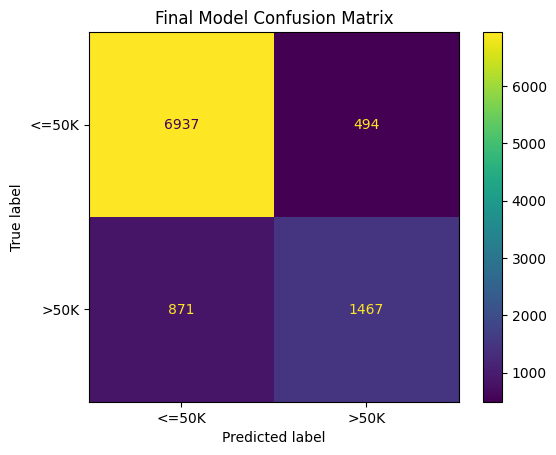

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_predictions,
    display_labels=[
        "<=50K",
        ">50K"
    ]
)

plt.title(
    "Final Model Confusion Matrix"
)

plt.show()

### Final Model Evaluation Observation

The final model achieved an overall accuracy of 0.86.

For individuals earning $50K or less, the model achieved a precision of 0.89, a recall of 0.93, and an F1-score of 0.91.

For individuals earning above $50K, the model achieved a precision of 0.75, a recall of 0.63, and an F1-score of 0.68.

Compared with the Part 1 model, recall for the above-$50K class increased slightly from 0.62 to 0.63. However, the model still performs better on the majority class and misses some individuals who actually earn above $50K.

## 9. Final Permutation Feature Importance

In [ ]:
final_importance_result = permutation_importance(
    final_model,
    X_test_fe,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring="f1",
    n_jobs=-1
)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [ ]:
final_importance_df = pd.DataFrame({
    "Feature": X_test_fe.columns,
    "Importance": (
        final_importance_result
        .importances_mean
    )
}).sort_values(
    "Importance",
    ascending=False
)

part2_top_features = final_importance_df.head(10)

part2_top_features

,Feature,Importance
4,marital_status,0.104841
9,capital_gain,0.092131
3,educational_num,0.074354
5,occupation,0.052384
0,age,0.051328
6,relationship,0.050998
10,capital_loss,0.030832
13,capital_status,0.030373
11,hours_per_week,0.016204
1,workclass,0.014122


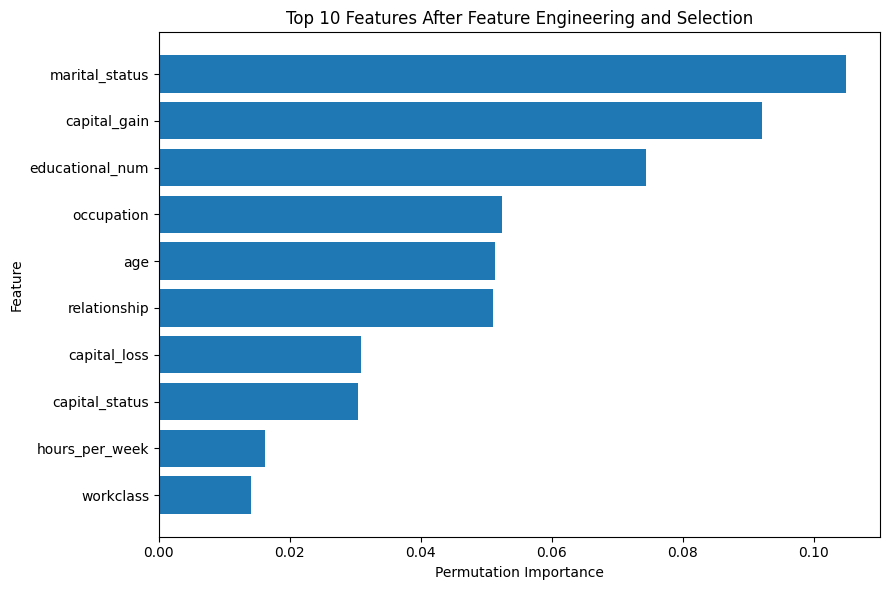

In [ ]:
plt.figure(figsize=(9, 6))

plt.barh(
    part2_top_features["Feature"][::-1],
    part2_top_features["Importance"][::-1]
)

plt.title(
    "Top 10 Features After Feature Engineering and Selection"
)

plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Top Feature Comparison

The final permutation-importance results were compared with the results from Part 1.

`marital_status` and `capital_gain` remained the two most important features. Other original features, including `educational_num`, `occupation`, `age`, and `relationship`, also remained influential.

The engineered feature `capital_status` appeared among the top 10 features, indicating that summarizing capital activity provided useful additional information to the model.

However, `work_hours_group` did not appear in the top 10. This suggests that the original numerical feature `hours_per_week` provided more useful information than grouping working hours into broad categories.

Compared with Part 1, `capital_status` entered the top 10, while `gender` was no longer included. Overall, the model continued to rely mainly on financial, educational, demographic, and employment-related features.

## 10. Top Feature Comparison

In [ ]:
part1_feature_names = set(
    part1_top_features["Feature"]
)

part2_feature_names = set(
    part2_top_features["Feature"]
)

new_top_features = (
    part2_feature_names -
    part1_feature_names
)

engineered_features_in_top_10 = [
    feature
    for feature in [
        "capital_status",
        "work_hours_group"
    ]
    if feature in part2_feature_names
]

print(
    "New features in the Part 2 top 10:",
    new_top_features
)

print(
    "Engineered features in the top 10:",
    engineered_features_in_top_10
)

New features in the Part 2 top 10: {'capital_status'}
Engineered features in the top 10: ['capital_status']


## Part 2 Conclusion

In Part 2, two new features were created: `capital_status` and `work_hours_group`.

The original Random Forest model achieved an accuracy of 0.86, an F1-score of 0.680, and a ROC-AUC score of 0.906.

After feature engineering, accuracy remained at 0.86, while the F1-score increased slightly to 0.683. ROC-AUC remained at 0.906. This indicates that the engineered features provided a small improvement in identifying the above-$50K class.

Embedded feature selection reduced the number of transformed features from 98 to 49. The final model maintained an accuracy of 0.86, achieved an F1-score of 0.682, and produced the highest ROC-AUC score of 0.907.

Although the improvement in predictive performance was small, feature selection created a simpler model using only half of the transformed features without meaningfully reducing performance.

Permutation importance showed that `marital_status`, `capital_gain`, `educational_num`, `occupation`, `age`, and `relationship` remained among the most important features. The engineered feature `capital_status` also appeared in the top 10, showing that it provided useful additional information.

In contrast, `work_hours_group` did not appear among the top features, suggesting that the original `hours_per_week` feature was more informative than the grouped version.

Overall, feature engineering slightly improved the F1-score, while feature selection reduced model complexity and maintained nearly the same predictive performance.